**Jakub Orchowski, s223281**

# CEL ĆWICZENIA
Implementacja oświetlenia Lamberta i Phonga dla dwóch trójkątów z użyciem z-bufora oraz prostych cieni rzucanych między obiektami przy rzutowaniu równoległym na płaszczyznę OXY.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

# Zadania

## Zadanie 1.
Generuję obrazy dwóch trójkątów w modelu Lamberta dla obu zadanych położeń punktowego źródła światła.
Korzystam z jednego pipeline'u renderingu: najpierw wyznaczam piksele należące do trójkątów, potem buduję bufory widocznych punktów metodą z-bufora, a na końcu sprawdzam dla każdego widocznego piksela, czy drugi trójkąt przecina odcinek prowadzący do źródła światła, co daje prosty cień twardy.

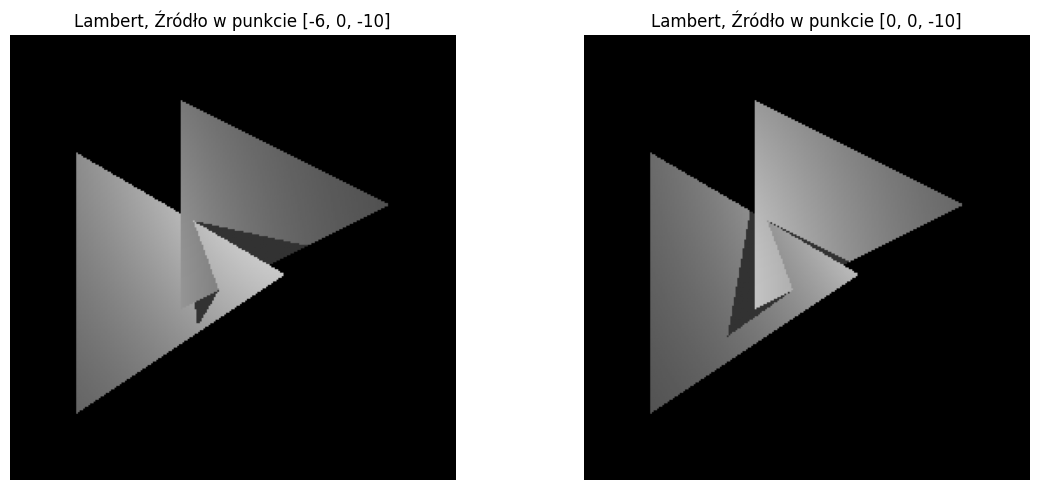

Źródło w punkcie [-6, 0, -10]: min = 50.00, max = 201.21, średnia = 128.72, piksele w cieniu = 623
Źródło w punkcie [0, 0, -10]: min = 50.00, max = 195.43, średnia = 127.53, piksele w cieniu = 708


In [2]:
from dataclasses import dataclass

IMAGE_SIZE = 256
PIXEL_SIZE = 0.1
AMBIENT_INTENSITY = 50.0
POINT_LIGHT_INTENSITY = 205.0
ATTENUATION_ALPHA = 0.001
SURFACE_REFLECTANCE = 1.0


def as_points(*points: tuple[float, float, float]) -> np.ndarray:
    return np.asarray(points, dtype=np.float64)


@dataclass(frozen=True)
class TriangleSurface:
    vertices: np.ndarray


@dataclass(frozen=True)
class TriangleSamples:
    vertices: np.ndarray
    face_normal: np.ndarray
    pixel_x: np.ndarray
    pixel_y: np.ndarray
    points: np.ndarray
    depths: np.ndarray


@dataclass(frozen=True)
class VisibleBuffers:
    point_buffer: np.ndarray
    normal_buffer: np.ndarray
    triangle_buffer: np.ndarray
    visible_mask: np.ndarray


@dataclass(frozen=True)
class RenderResult:
    image: np.ndarray
    visible_mask: np.ndarray
    shadow_mask: np.ndarray


LIGHT_CASES = {
    "Źródło w punkcie [-6, 0, -10]": np.array([-6.0, 0.0, -10.0], dtype=np.float64),
    "Źródło w punkcie [0, 0, -10]": np.array([0.0, 0.0, -10.0], dtype=np.float64),
}

SCENE_TRIANGLES = [
    TriangleSurface(vertices=as_points((9.0, 3.0, 16.0), (-3.0, 9.0, 6.0), (-3.0, -3.0, 4.0))),
    TriangleSurface(vertices=as_points((3.0, -1.0, 2.0), (-9.0, 6.0, 10.0), (-9.0, -9.0, 18.0))),
]


def create_coordinate_axes(image_size: int, pixel_size: float) -> tuple[np.ndarray, np.ndarray]:
    """Tworzy współrzędne środków pikseli dla obrazu o zadanym rozmiarze."""
    x_coordinates = (np.arange(image_size) + 0.5 - image_size / 2.0) * pixel_size
    y_coordinates = (image_size / 2.0 - (np.arange(image_size) + 0.5)) * pixel_size
    return x_coordinates, y_coordinates



def barycentric_inverse(projected_vertices: np.ndarray) -> np.ndarray:
    """Przygotowuje macierz odwrotną do szybkiego liczenia wag barycentrycznych."""
    return np.linalg.inv(np.vstack((projected_vertices.T, np.ones(3))))



def face_normal(vertices: np.ndarray) -> np.ndarray:
    """Wyznacza znormalizowany wektor normalny skierowany do obserwatora."""
    normal = np.cross(vertices[1] - vertices[0], vertices[2] - vertices[0])
    normal = normal / np.linalg.norm(normal)
    if normal[2] > 0.0:
        normal = -normal
    return normal



def point_light_factor(distances: np.ndarray) -> np.ndarray:
    """Wyznacza tłumienie światła punktowego zależne od odległości."""
    return 1.0 / (1.0 + ATTENUATION_ALPHA * distances * distances)



def lambert_intensity(points: np.ndarray, normals: np.ndarray, light_position: np.ndarray) -> np.ndarray:
    """Oblicza jasności punktów zgodnie z modelem Lamberta."""
    light_vectors = light_position - points
    distances = np.linalg.norm(light_vectors, axis=1)
    safe_distances = np.where(distances == 0.0, 1.0, distances)
    light_directions = light_vectors / safe_distances[:, None]
    cosines = np.clip(np.sum(normals * light_directions, axis=1), 0.0, None)
    diffuse = POINT_LIGHT_INTENSITY * SURFACE_REFLECTANCE * cosines * point_light_factor(safe_distances)
    return AMBIENT_INTENSITY * SURFACE_REFLECTANCE + diffuse



def phong_intensity(
    points: np.ndarray,
    normals: np.ndarray,
    light_position: np.ndarray,
    eye_position: np.ndarray,
    shininess: float,
) -> np.ndarray:
    """Oblicza jasności punktów zgodnie z modelem odbicia Phonga."""
    light_vectors = light_position - points
    light_distances = np.linalg.norm(light_vectors, axis=1)
    safe_light_distances = np.where(light_distances == 0.0, 1.0, light_distances)
    light_directions = light_vectors / safe_light_distances[:, None]
    diffuse_cosines = np.clip(np.sum(normals * light_directions, axis=1), 0.0, None)
    diffuse = POINT_LIGHT_INTENSITY * SURFACE_REFLECTANCE * diffuse_cosines

    view_vectors = eye_position - points
    view_distances = np.linalg.norm(view_vectors, axis=1)
    safe_view_distances = np.where(view_distances == 0.0, 1.0, view_distances)
    view_directions = view_vectors / safe_view_distances[:, None]

    reflection_directions = 2.0 * diffuse_cosines[:, None] * normals - light_directions
    reflection_norms = np.linalg.norm(reflection_directions, axis=1)
    safe_reflection_norms = np.where(reflection_norms == 0.0, 1.0, reflection_norms)
    reflection_directions = reflection_directions / safe_reflection_norms[:, None]
    specular_cosines = np.clip(np.sum(reflection_directions * view_directions, axis=1), 0.0, None)
    specular = POINT_LIGHT_INTENSITY * np.where(diffuse_cosines > 0.0, specular_cosines**shininess, 0.0)

    return AMBIENT_INTENSITY * SURFACE_REFLECTANCE + (diffuse + specular) * point_light_factor(safe_light_distances)



def build_triangle_samples(
    x_coordinates: np.ndarray,
    y_coordinates: np.ndarray,
    triangles: list[TriangleSurface],
) -> list[TriangleSamples]:
    """Przygotowuje próbki wszystkich pikseli należących do każdego trójkąta."""
    samples: list[TriangleSamples] = []

    for triangle in triangles:
        vertices = triangle.vertices
        inverse_matrix = barycentric_inverse(vertices[:, :2])
        x_min, x_max = vertices[:, 0].min(), vertices[:, 0].max()
        y_min, y_max = vertices[:, 1].min(), vertices[:, 1].max()

        x_indices = np.where((x_coordinates >= x_min - PIXEL_SIZE) & (x_coordinates <= x_max + PIXEL_SIZE))[0]
        y_indices = np.where((y_coordinates >= y_min - PIXEL_SIZE) & (y_coordinates <= y_max + PIXEL_SIZE))[0]
        pixel_x_grid, pixel_y_grid = np.meshgrid(x_indices, y_indices)
        candidate_points = np.column_stack(
            (
                x_coordinates[pixel_x_grid.ravel()],
                y_coordinates[pixel_y_grid.ravel()],
                np.ones(pixel_x_grid.size),
            )
        )
        weights = (inverse_matrix @ candidate_points.T).T
        inside_mask = np.min(weights, axis=1) >= -1e-9

        pixel_x = pixel_x_grid.ravel()[inside_mask]
        pixel_y = pixel_y_grid.ravel()[inside_mask]
        barycentric_weights = weights[inside_mask]
        points = barycentric_weights @ vertices
        depths = points[:, 2]

        samples.append(
            TriangleSamples(
                vertices=vertices,
                face_normal=face_normal(vertices),
                pixel_x=pixel_x,
                pixel_y=pixel_y,
                points=points,
                depths=depths,
            )
        )

    return samples



def ray_intersects_triangle(
    origin: np.ndarray,
    direction: np.ndarray,
    vertices: np.ndarray,
    max_distance: float,
) -> bool:
    """Sprawdza przecięcie odcinka ze ścianą trójkąta metodą Möllera i Trumbore'a."""
    edge1 = vertices[1] - vertices[0]
    edge2 = vertices[2] - vertices[0]
    p_vector = np.cross(direction, edge2)
    determinant = float(np.dot(edge1, p_vector))

    if abs(determinant) < 1e-9:
        return False

    inverse_determinant = 1.0 / determinant
    t_vector = origin - vertices[0]
    u_parameter = inverse_determinant * float(np.dot(t_vector, p_vector))
    if u_parameter < 0.0 or u_parameter > 1.0:
        return False

    q_vector = np.cross(t_vector, edge1)
    v_parameter = inverse_determinant * float(np.dot(direction, q_vector))
    if v_parameter < 0.0 or u_parameter + v_parameter > 1.0:
        return False

    distance = inverse_determinant * float(np.dot(edge2, q_vector))
    return 1e-6 < distance < max_distance - 1e-6



def point_in_shadow(
    point: np.ndarray,
    light_position: np.ndarray,
    triangle_index: int,
    triangle_samples: list[TriangleSamples],
) -> bool:
    """Sprawdza, czy promień do źródła światła jest zasłonięty przez drugi trójkąt."""
    direction = light_position - point
    distance = float(np.linalg.norm(direction))
    if distance == 0.0:
        return False
    direction = direction / distance
    origin = point + direction * 1e-4

    for other_index, other_triangle in enumerate(triangle_samples):
        if other_index == triangle_index:
            continue
        if ray_intersects_triangle(origin, direction, other_triangle.vertices, distance):
            return True

    return False



def build_visible_buffers(triangle_samples: list[TriangleSamples]) -> VisibleBuffers:
    """Buduje bufory widocznych punktów, normalnych i indeksów trójkątów."""
    z_buffer = np.full((IMAGE_SIZE, IMAGE_SIZE), np.inf, dtype=np.float64)
    point_buffer = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.float64)
    normal_buffer = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.float64)
    triangle_buffer = np.full((IMAGE_SIZE, IMAGE_SIZE), -1, dtype=np.int32)

    for triangle_index, triangle in enumerate(triangle_samples):
        pixel_y = triangle.pixel_y
        pixel_x = triangle.pixel_x
        closer_mask = triangle.depths < z_buffer[pixel_y, pixel_x]

        z_buffer[pixel_y[closer_mask], pixel_x[closer_mask]] = triangle.depths[closer_mask]
        point_buffer[pixel_y[closer_mask], pixel_x[closer_mask]] = triangle.points[closer_mask]
        normal_buffer[pixel_y[closer_mask], pixel_x[closer_mask]] = triangle.face_normal
        triangle_buffer[pixel_y[closer_mask], pixel_x[closer_mask]] = triangle_index

    visible_mask = triangle_buffer >= 0
    return VisibleBuffers(
        point_buffer=point_buffer,
        normal_buffer=normal_buffer,
        triangle_buffer=triangle_buffer,
        visible_mask=visible_mask,
    )



def compute_shadow_mask(
    buffers: VisibleBuffers,
    triangle_samples: list[TriangleSamples],
    light_position: np.ndarray,
) -> np.ndarray:
    """Wyznacza maskę pikseli pozostających w cieniu dla danego źródła światła."""
    shadow_mask = np.zeros_like(buffers.visible_mask)
    visible_pixels = np.argwhere(buffers.visible_mask)

    for pixel_y, pixel_x in visible_pixels:
        point = buffers.point_buffer[pixel_y, pixel_x]
        triangle_index = int(buffers.triangle_buffer[pixel_y, pixel_x])
        shadow_mask[pixel_y, pixel_x] = point_in_shadow(point, light_position, triangle_index, triangle_samples)

    return shadow_mask



def render_scene(
    triangle_samples: list[TriangleSamples],
    light_position: np.ndarray,
    lighting_model: str = "lambert",
    eye_position: np.ndarray | None = None,
    shininess: float | None = None,
) -> RenderResult:
    """Renderuje scenę dla modelu Lamberta albo Phonga z uwzględnieniem cieni."""
    buffers = build_visible_buffers(triangle_samples)
    shadow_mask = compute_shadow_mask(buffers, triangle_samples, light_position)

    image = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.float64)
    visible_pixels = np.argwhere(buffers.visible_mask)

    for pixel_y, pixel_x in visible_pixels:
        point = buffers.point_buffer[pixel_y, pixel_x][None, :]
        normal = buffers.normal_buffer[pixel_y, pixel_x][None, :]
        if shadow_mask[pixel_y, pixel_x]:
            intensity = AMBIENT_INTENSITY
        elif lighting_model == "phong":
            intensity = phong_intensity(point, normal, light_position, eye_position, shininess)[0]
        else:
            intensity = lambert_intensity(point, normal, light_position)[0]
        image[pixel_y, pixel_x] = np.clip(intensity, 0.0, 255.0)

    return RenderResult(image=image, visible_mask=buffers.visible_mask, shadow_mask=shadow_mask)



def show_result_grid(
    panels: list[tuple[str, RenderResult]],
    rows: int,
    columns: int,
    figsize: tuple[float, float],
) -> None:
    """Wyświetla siatkę wygenerowanych obrazów."""
    fig, axes = plt.subplots(rows, columns, figsize=figsize)
    axes_array = np.atleast_1d(axes).ravel()

    for axis, (title, result) in zip(axes_array, panels):
        axis.imshow(result.image, cmap="gray", vmin=0, vmax=255)
        axis.set_title(title)
        axis.axis("off")

    for axis in axes_array[len(panels):]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()



def summarize_render(label: str, result: RenderResult) -> None:
    """Wypisuje podstawowe statystyki wygenerowanego obrazu."""
    visible_pixels = result.image[result.visible_mask]
    print(
        f"{label}: min = {visible_pixels.min():.2f}, max = {visible_pixels.max():.2f}, "
        f"średnia = {visible_pixels.mean():.2f}, piksele w cieniu = {int(result.shadow_mask.sum())}"
    )


X_COORDINATES, Y_COORDINATES = create_coordinate_axes(IMAGE_SIZE, PIXEL_SIZE)
TRIANGLE_SAMPLES = build_triangle_samples(X_COORDINATES, Y_COORDINATES, SCENE_TRIANGLES)

lab10_lambert_results: dict[str, RenderResult] = {}
lambert_panels: list[tuple[str, RenderResult]] = []

for label, light_position in LIGHT_CASES.items():
    result = render_scene(TRIANGLE_SAMPLES, light_position, lighting_model="lambert")
    lab10_lambert_results[label] = result
    lambert_panels.append((f"Lambert, {label}", result))

show_result_grid(lambert_panels, rows=1, columns=len(LIGHT_CASES), figsize=(12, 5))

for label, result in lab10_lambert_results.items():
    summarize_render(label, result)

### Wnioski
Połączenie z-bufora z testem przecięcia odcinka do źródła pozwala jednocześnie odtworzyć wzajemne przesłanianie oraz proste cienie rzucane między trójkątami.
Zmiana położenia źródła światła wpływa nie tylko na jasność, ale także na zasięg cienia, ponieważ zmienia się kierunek promieni padających na powierzchnie.

## Zadanie 2.
Powtarzam zadanie 1 w modelu odbicia Phonga dla parametrów m równych 5, 15 i 50 oraz dla obu konfiguracji światła i obserwatora podanych w instrukcji.
Zachowuję ten sam pipeline widoczności i cienia co w zadaniu Lambertowskim, zmieniając jedynie lokalny model oświetlenia oraz położenie oka obserwatora.

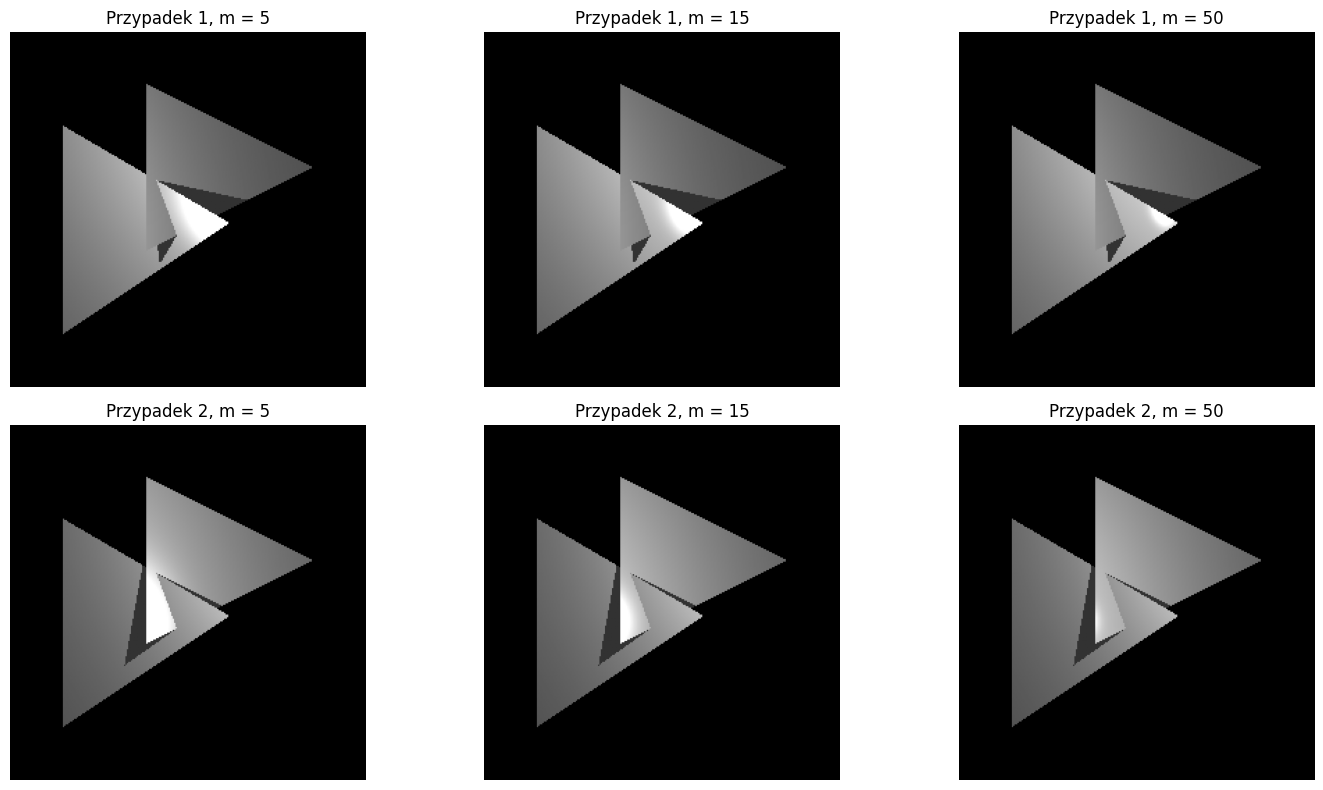

Światło [-6, 0, -10], oko [-3, -5, 0], m = 5: min = 50.00, max = 255.00, średnia = 132.13, piksele w cieniu = 623
Światło [-6, 0, -10], oko [-3, -5, 0], m = 15: min = 50.00, max = 255.00, średnia = 130.31, piksele w cieniu = 623
Światło [-6, 0, -10], oko [-3, -5, 0], m = 50: min = 50.00, max = 255.00, średnia = 129.36, piksele w cieniu = 623
Światło [0, 0, -10], oko [5, 0, 0], m = 5: min = 50.00, max = 255.00, średnia = 131.48, piksele w cieniu = 708
Światło [0, 0, -10], oko [5, 0, 0], m = 15: min = 50.00, max = 255.00, średnia = 129.19, piksele w cieniu = 708
Światło [0, 0, -10], oko [5, 0, 0], m = 50: min = 50.00, max = 250.65, średnia = 127.80, piksele w cieniu = 708


In [3]:
PHONG_EXPONENTS = [5, 15, 50]
PHONG_CASES = [
    (
        "Światło [-6, 0, -10], oko [-3, -5, 0]",
        LIGHT_CASES["Źródło w punkcie [-6, 0, -10]"],
        np.array([-3.0, -5.0, 0.0], dtype=np.float64),
    ),
    (
        "Światło [0, 0, -10], oko [5, 0, 0]",
        LIGHT_CASES["Źródło w punkcie [0, 0, -10]"],
        np.array([5.0, 0.0, 0.0], dtype=np.float64),
    ),
]

lab10_phong_results: dict[tuple[str, int], RenderResult] = {}
phong_panels: list[tuple[str, RenderResult]] = []

for row_index, (case_label, light_position, eye_position) in enumerate(PHONG_CASES, start=1):
    for shininess in PHONG_EXPONENTS:
        result = render_scene(
            TRIANGLE_SAMPLES,
            light_position,
            lighting_model="phong",
            eye_position=eye_position,
            shininess=shininess,
        )
        lab10_phong_results[(case_label, shininess)] = result
        phong_panels.append((f"Przypadek {row_index}, m = {shininess}", result))

show_result_grid(
    phong_panels,
    rows=len(PHONG_CASES),
    columns=len(PHONG_EXPONENTS),
    figsize=(15, 8),
)

for (case_label, shininess), result in lab10_phong_results.items():
    summarize_render(f"{case_label}, m = {shininess}", result)

### Wnioski
Wraz ze wzrostem parametru m składnik lustrzany skupia się na coraz mniejszym obszarze, przez co refleks staje się ostrzejszy i bardziej kontrastowy.
Zmiana położenia oka obserwatora przesuwa obszary największego połysku, natomiast z-bufor i test cienia nadal zapewniają poprawną widoczność sceny.